<a href="https://colab.research.google.com/github/nikasvesko/repic/blob/main/decisiontree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
data = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/classification_data.csv')
data

,Sample code number,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
678,776715,3,1,1,1,3,2,1,1,1,2
679,841769,2,1,1,1,2,1,1,1,1,2
680,888820,5,10,10,3,7,3,8,10,2,4
681,897471,4,8,6,4,3,4,10,6,1,4


In [4]:
data = pd.read_csv('https://github.com/bio-chem-info/python_course/raw/refs/heads/main/classification_data.csv', index_col=0)
data

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
Sample code number,,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1,2
1002945,5,4,4,5,7,10,3,2,1,2
1015425,3,1,1,1,2,2,3,1,1,2
1016277,6,8,8,1,3,4,3,7,1,2
1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...
776715,3,1,1,1,3,2,1,1,1,2
841769,2,1,1,1,2,1,1,1,1,2
888820,5,10,10,3,7,3,8,10,2,4


In [5]:
from sklearn.model_selection import train_test_split
x = data.iloc[:, :-1]
y= data.iloc[:,-1]

In [6]:
x.head()

,Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
Sample code number,,,,,,,,,
1000025,5,1,1,1,2,1,3,1,1
1002945,5,4,4,5,7,10,3,2,1
1015425,3,1,1,1,2,2,3,1,1
1016277,6,8,8,1,3,4,3,7,1
1017023,4,1,1,3,2,1,3,1,1


In [7]:
y

,Class
Sample code number,
1000025,2
1002945,2
1015425,2
1016277,2
1017023,2
...,...
776715,2
841769,2
888820,4


In [8]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state=0)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train= scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(criterion ='gini', random_state = 0, max_depth = 4, class_weight = 'balanced') #težine za svaku klasu
tree.fit(x_train, y_train) #max depth je koliko najvise cvorova

DecisionTreeClassifier(class_weight='balanced', max_depth=4, random_state=0)

[Text(0.47115384615384615, 0.9, 'Uniformity of Cell Size <= -0.207\ngini = 0.5\nsamples = 512\nvalue = [256.0, 256.0]'),
 Text(0.25, 0.7, 'Bare Nuclei <= 0.702\ngini = 0.08\nsamples = 315\nvalue = [233.97, 10.24]'),
 Text(0.3605769230769231, 0.8, 'True  '),
 Text(0.15384615384615385, 0.5, 'Bare Nuclei <= 0.011\ngini = 0.024\nsamples = 309\nvalue = [233.211, 2.926]'),
 Text(0.07692307692307693, 0.3, 'Bare Nuclei <= -0.543\ngini = 0.0\nsamples = 299\nvalue = [227.134, 0.0]'),
 Text(0.038461538461538464, 0.1, 'gini = 0.0\nsamples = 279\nvalue = [211.941, 0.0]'),
 Text(0.11538461538461539, 0.1, 'gini = 0.0\nsamples = 20\nvalue = [15.193, 0.0]'),
 Text(0.23076923076923078, 0.3, 'Bland Chromatin <= -0.787\ngini = 0.439\nsamples = 10\nvalue = [6.077, 2.926]'),
 Text(0.19230769230769232, 0.1, 'gini = 0.0\nsamples = 6\nvalue = [4.558, 0.0]'),
 Text(0.2692307692307692, 0.1, 'gini = 0.45\nsamples = 4\nvalue = [1.519, 2.926]'),
 Text(0.34615384615384615, 0.5, 'Clump Thickness <= -0.686\ngini = 0.1

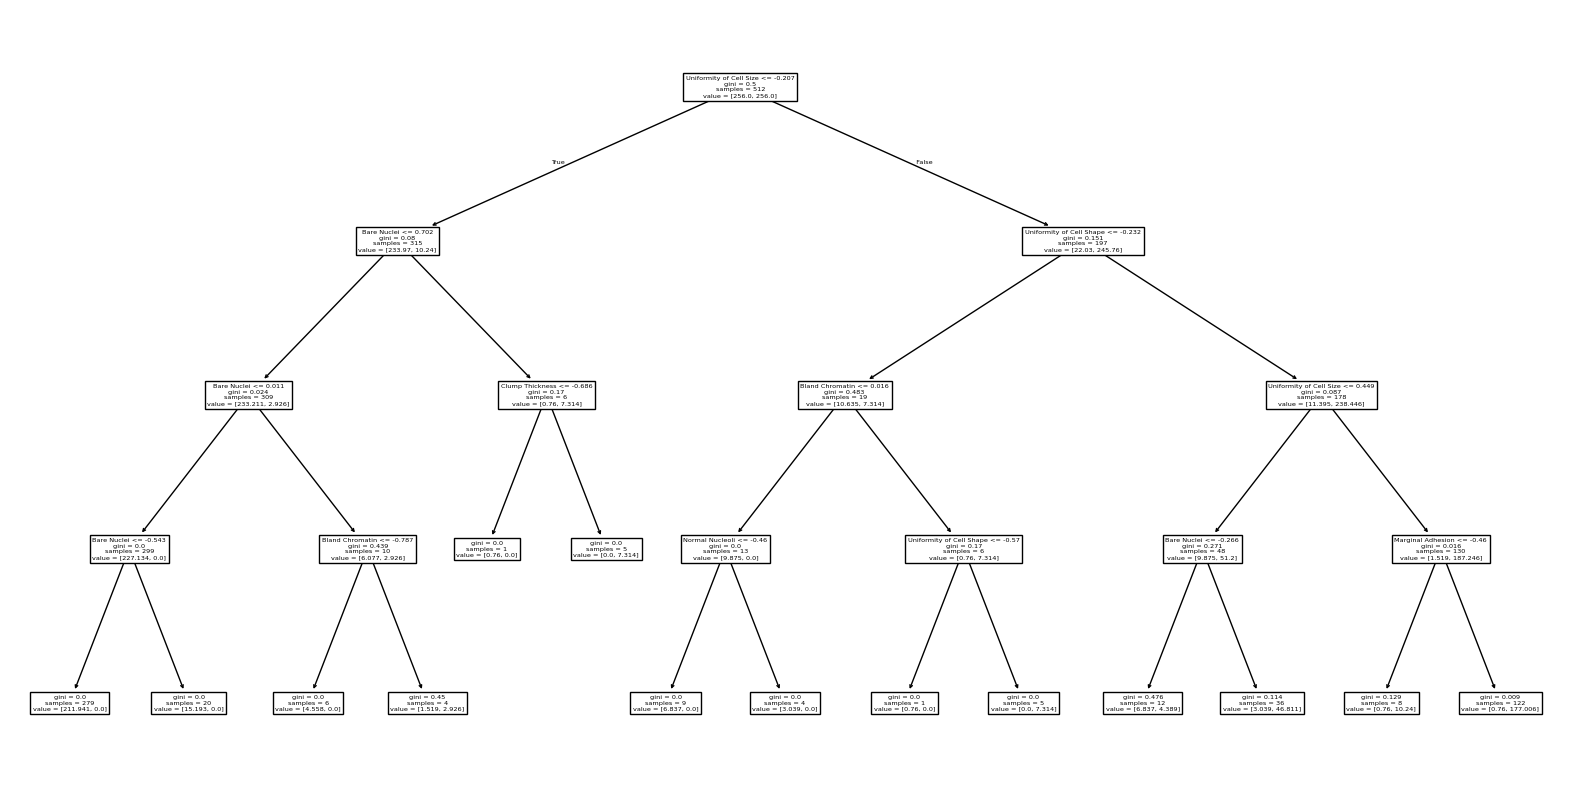

In [19]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(tree, feature_names= x.columns) #x dataset

In [20]:
y_pred = tree.predict(x_test)
y_pred

array([2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 4, 2, 2, 2,
       4, 2, 4, 4, 2, 2, 2, 4, 2, 4, 4, 2, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2,
       2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2,
       2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 4, 2, 4, 2, 2, 4, 2, 4,
       4, 2, 4, 2, 4, 2, 4, 4, 4, 4, 4, 2, 2, 2, 4, 4, 2, 2, 4, 4, 2, 2,
       4, 2, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2,
       4, 2, 2, 4, 2, 4, 2, 2, 2, 2, 2, 2, 2, 4, 4, 2, 4, 2, 4, 4, 2, 2,
       2, 2, 4, 4, 2, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2])

In [21]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
cm

array([[102,   5],
       [  3,  61]])

In [22]:
accuracy_score(y_test, y_pred)


0.9532163742690059

In [23]:
from sklearn.ensemble import RandomForestClassifier
rf= RandomForestClassifier(n_estimators = 200, max_depth= 6, criterion = 'gini', random_state=0, class_weight = 'balanced')
rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6, n_estimators=200,
                       random_state=0)

In [24]:
y_pred_rf = rf.predict(x_test)

In [25]:
y_pred_rf

array([2, 2, 4, 4, 2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 4, 2, 2, 2,
       4, 2, 4, 4, 2, 2, 2, 4, 2, 4, 4, 2, 2, 2, 4, 4, 2, 4, 2, 2, 2, 2,
       2, 2, 2, 4, 2, 2, 4, 2, 4, 2, 2, 2, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2,
       2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 4, 2, 4, 2, 2, 4, 2, 4,
       4, 2, 4, 2, 4, 4, 2, 4, 4, 4, 4, 2, 2, 2, 4, 4, 2, 2, 4, 2, 2, 2,
       4, 2, 2, 4, 2, 2, 2, 4, 2, 2, 2, 4, 2, 2, 4, 4, 2, 4, 2, 4, 2, 2,
       4, 2, 2, 4, 2, 2, 2, 2, 2, 4, 2, 2, 2, 4, 4, 2, 4, 2, 4, 4, 2, 2,
       2, 2, 4, 4, 2, 4, 4, 4, 4, 2, 4, 2, 2, 2, 2, 2, 2])

In [26]:
c_m = confusion_matrix (y_test, y_pred)
c_m

array([[102,   5],
       [  3,  61]])

In [27]:
accuracy_score(y_test, y_pred)

0.9532163742690059